ESERCIZIO

Implementa un Autoencoder per CIFAR-10 con un bottleneck di256 neuroni
Confronta visivamente la qualità della ricostruzione utilizzando prima la funzione di perdia MSE epoi MAE per 10 epoche
Suggerimento: usa plt.subplot per mostrare input, ricostruzione MSE e ricostruzione MAE in una griglia

Caricamento e normalizzazione CIFAR-10...

--- Training con MSE (Mean Squared Error) ---
--- Training con MAE (Mean Absolute Error) ---

Generazione delle ricostruzioni per il confronto...


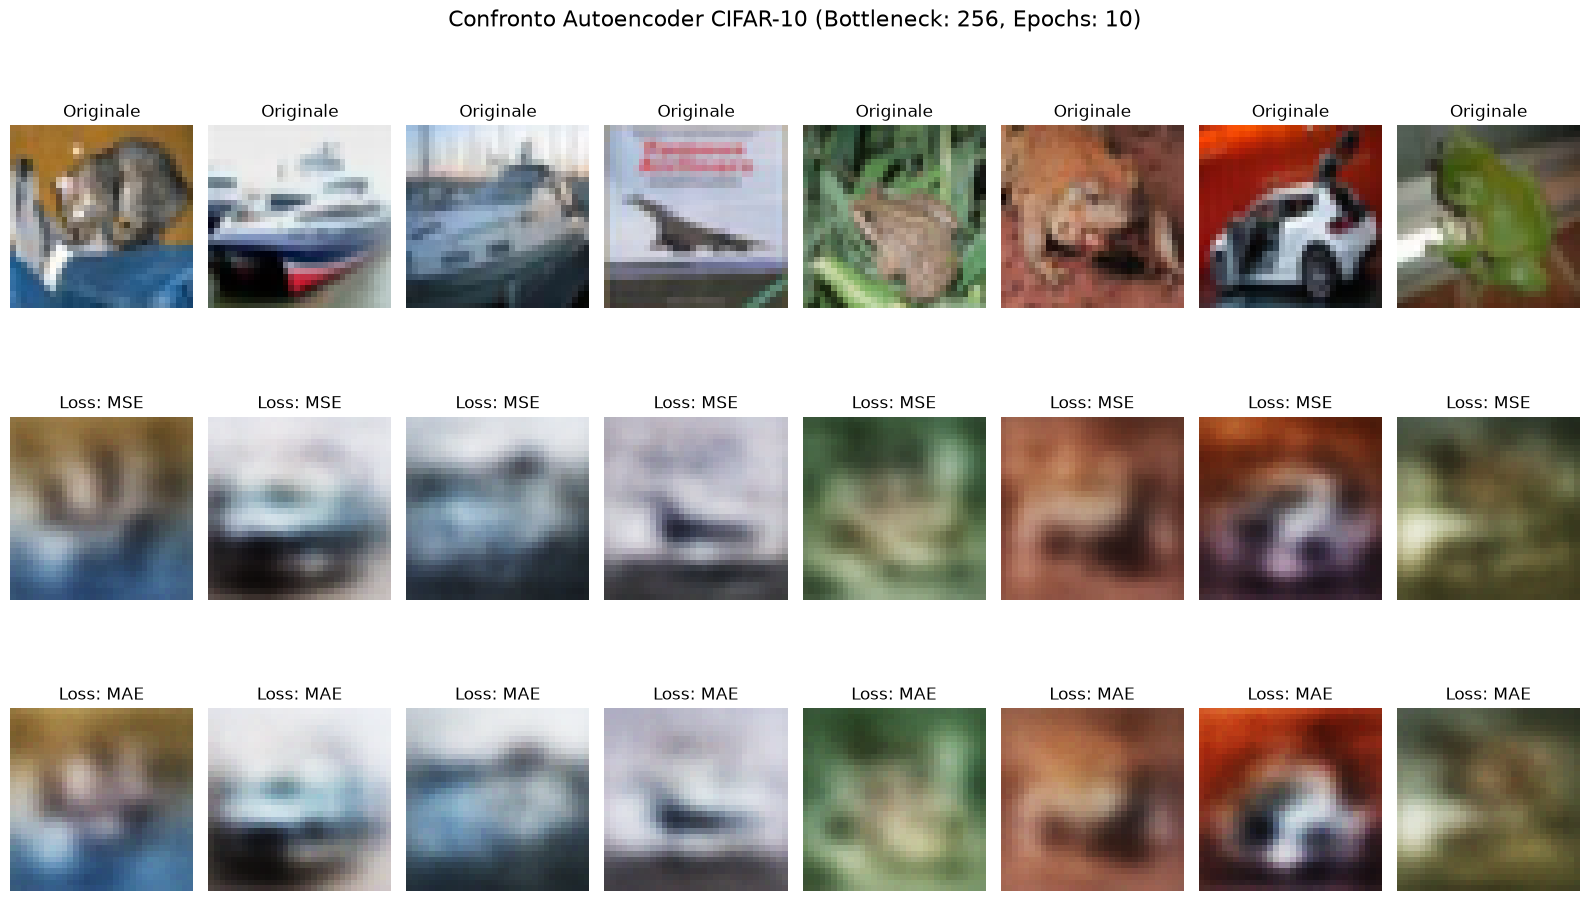


--- Analisi Completata ---


In [1]:
import os

# 1. Configurazione Backend: PyTorch
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------------------
# Preparazione Dati
# -----------------------------------------------------------------------------------------
print("Caricamento e normalizzazione CIFAR-10...")
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flattening per layer densi: 32*32*3 = 3072
input_dim = 3072
x_train_flat = x_train.reshape((-1, input_dim))
x_test_flat = x_test.reshape((-1, input_dim))

# -----------------------------------------------------------------------------------------
# Definizione Architettura (Functional API)
# -----------------------------------------------------------------------------------------
def build_autoencoder(bottleneck_dim=256):
    inputs = keras.Input(shape=(input_dim,))
    
    # Encoder
    enc = layers.Dense(512, activation='relu')(inputs)
    bottleneck = layers.Dense(bottleneck_dim, activation='relu', name="bottleneck")(enc)
    
    # Decoder
    dec = layers.Dense(512, activation='relu')(bottleneck)
    outputs = layers.Dense(input_dim, activation='sigmoid')(dec)
    
    return keras.Model(inputs, outputs)

# -----------------------------------------------------------------------------------------
# Training Comparativo (10 Epoche)
# -----------------------------------------------------------------------------------------
epochs = 10
batch_size = 256

# Modello 1: Ottimizzazione tramite MSE
print("\n--- Training con MSE (Mean Squared Error) ---")
model_mse = build_autoencoder()
model_mse.compile(optimizer='adam', loss='mse')
model_mse.fit(x_train_flat, x_train_flat, epochs=epochs, batch_size=batch_size, verbose=0)

# Modello 2: Ottimizzazione tramite MAE
print("--- Training con MAE (Mean Absolute Error) ---")
model_mae = build_autoencoder()
model_mae.compile(optimizer='adam', loss='mae')
model_mae.fit(x_train_flat, x_train_flat, epochs=epochs, batch_size=batch_size, verbose=0)

# -----------------------------------------------------------------------------------------
# Visualizzazione Risultati (Input, MSE, MAE)
# -----------------------------------------------------------------------------------------
print("\nGenerazione delle ricostruzioni per il confronto...")
decoded_mse = model_mse.predict(x_test_flat, verbose=0)
decoded_mae = model_mae.predict(x_test_flat, verbose=0)

# Utilizziamo ops.convert_to_numpy per gestire in sicurezza i tensori PyTorch/GPU
decoded_mse = ops.convert_to_numpy(decoded_mse)
decoded_mae = ops.convert_to_numpy(decoded_mae)

n = 8  # Numero di campioni da mostrare
plt.figure(figsize=(16, 10))
plt.suptitle(f'Confronto Autoencoder CIFAR-10 (Bottleneck: 256, Epochs: {epochs})', fontsize=16)

for i in range(n):
    # 1. INPUT ORIGINALE
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Originale")
    plt.axis("off")

    # 2. RICOSTRUZIONE MSE
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_mse[i].reshape(32, 32, 3))
    plt.title("Loss: MSE")
    plt.axis("off")

    # 3. RICOSTRUZIONE MAE
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_mae[i].reshape(32, 32, 3))
    plt.title("Loss: MAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("\n--- Analisi Completata ---")